In [46]:
# Task 1 — Data Exploration with Pandas
import pandas as pd

df=pd.read_csv("students.csv")

pd.set_option('display.max_columns',None)
pd.set_option('display.width',1000)

# 1.Print the first 5 rows using .head()
print('\n---First 5 rows---')
print(df.head())

# 2.Print the shape (rows × columns) and the data type of each column using .dtypes.
print("\n--- Shape and data types ---")
print(df.shape)
print(df.dtypes)

# 3.Print summary statistics (mean, min, max, std) for all numeric columns using .describe()
print("\n--- Summary Statistics ---")
print(df.describe())

# 4.Print the count of students who passed and who failed.
print("\n--- Pass/Fail Count ---")
print(df['passed'].value_counts())

# 5.Compute and print the average score per subject
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\n--- Average Scores (Passed Students) ---")
print(df[df['passed'] == 1][subject_cols].mean()) # only filters students who passed and for each subject returns its mean

print("\n--- Average Scores (Failed Students) ---")
print(df[df['passed'] == 0][subject_cols].mean()) # only filters students who failed and for each subject returns its mean

# 6.Find and print the student with the highest overall average across all 5 subjects.
df['overall_avg'] = df[subject_cols].mean(axis=1) # creates a new column that calculates the mean of subject marks for each student row

top_student = df.loc[df['overall_avg'].idxmax()] # locates the id with max student mean

print("\n--- Top Student ---")
print(f"{top_student['name']} with average {top_student['overall_avg']:.2f}")


---First 5 rows---
      name  math  science  english  history  pe  attendance_pct  study_hours_per_day  passed
0    Alice    88       92       76       80  95              92                  4.5       1
1      Bob    42       55       48       50  60              65                  1.2       0
2  Charlie    75       70       80       68  88              85                  3.0       1
3    Diana    95       98       91       89  97              98                  6.0       1
4      Eve    38       42       50       45  55              58                  0.8       0

--- Shape and data types ---
(15, 9)
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- Summary Statistics ---
            math    science    english    history         pe  a

In [47]:
# Task 2 — Data Visualization with Matplotlib
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

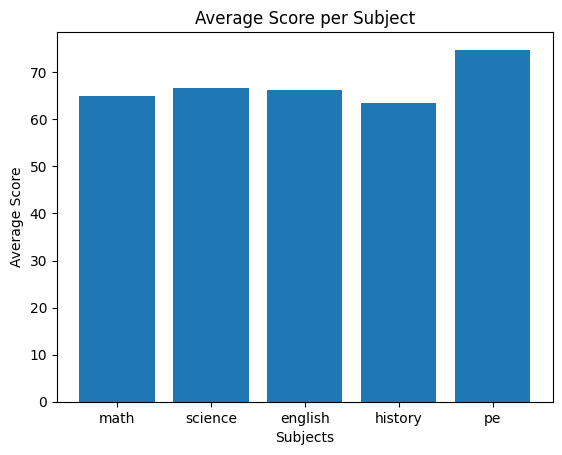

In [48]:
# task 2.1 - Bar Chart: Average score per subject across all students
avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

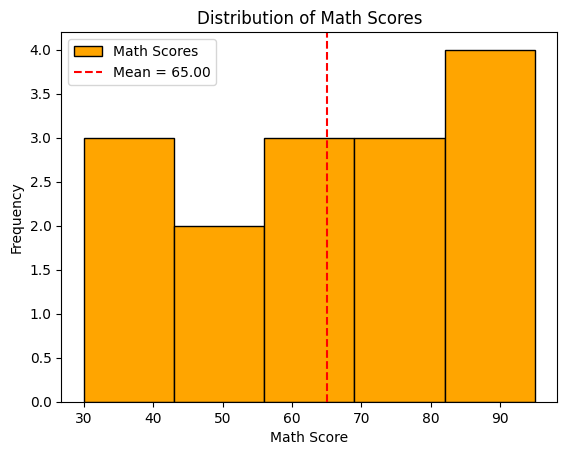

In [49]:
# task 2.2 - Histogram: Distribution of math scores.
plt.figure()

plt.hist(df['math'], bins=5, color='orange', edgecolor='black', label='Math Scores')

mean_math = df['math'].mean()
plt.axvline(mean_math,color='red', linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_histogram.png")
plt.show()

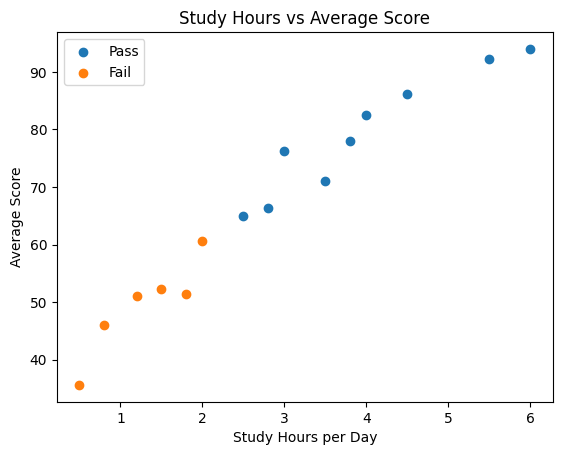

In [50]:
# task 2.3 - Scatter Plot: study_hours_per_day (x-axis) vs avg_score (y-axis).
plt.figure()

# Passed students
passed = df[df['passed'] == 1]
plt.scatter(passed['study_hours_per_day'], passed['avg_score'], label='Pass')

# Failed students
failed = df[df['passed'] == 0]
plt.scatter(failed['study_hours_per_day'], failed['avg_score'], label='Fail')

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_2698/4193937709.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


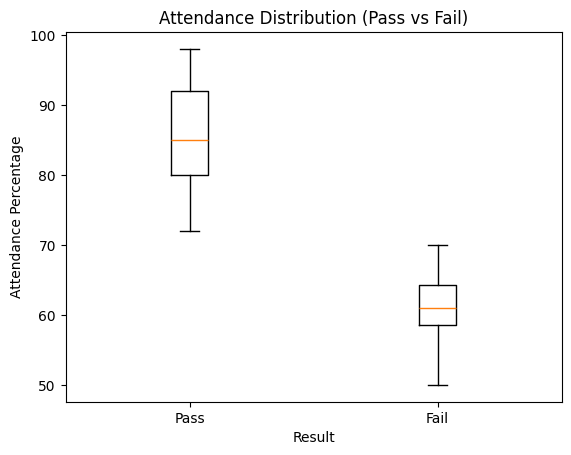

In [51]:
# task 2.4 - Box Plot: Show the distribution of attendance_pct for passing students vs failing students
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")

plt.savefig("plot4_box.png")
plt.show()

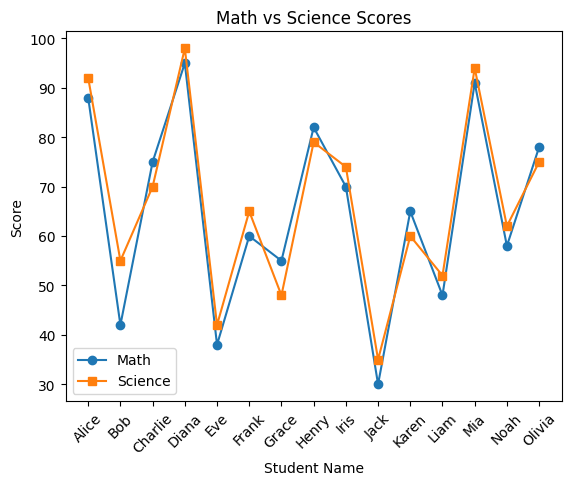

In [52]:
# task 2.5 - Line Plot: Plot the math score and science score for every student.
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')

plt.title("Math vs Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

In [53]:
# Task 3 — Data Visualization with Seaborn
!pip install seaborn



In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

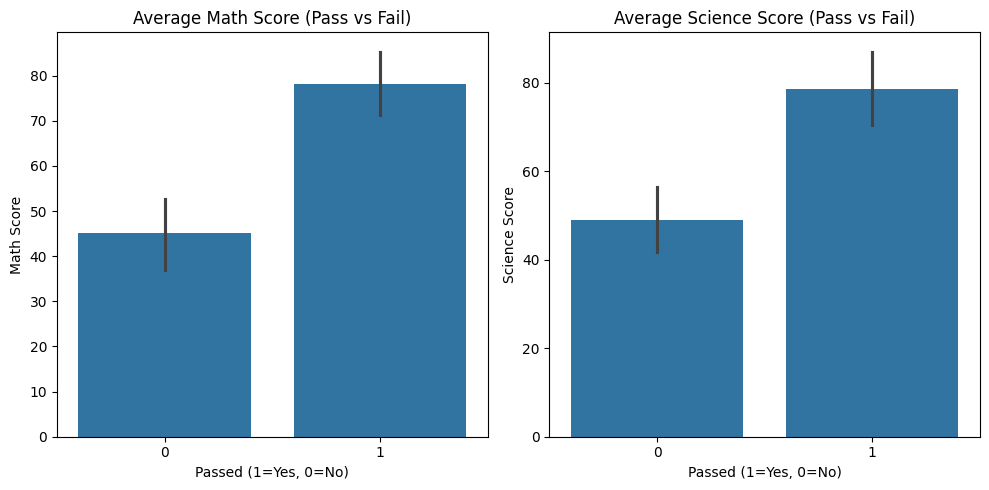

In [55]:
# task 3.1 - Seaborn bar plot: showing the average math and science score, split by(Pass vs Fail).
plt.figure(figsize=(10, 5))

# Subplot 1 — Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (1=Yes, 0=No)")
ax1.set_ylabel("Math Score")

# Subplot 2 — Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (1=Yes, 0=No)")
ax2.set_ylabel("Science Score")

plt.tight_layout()

plt.savefig("plot6_seaborn_bar.png")
plt.show()

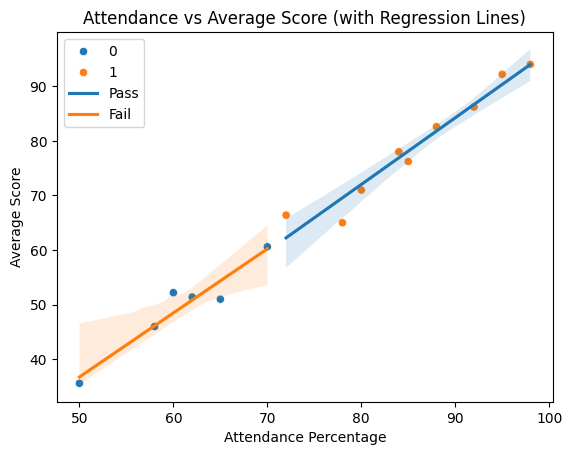

In [56]:
# task 3.2 - Seaborn scatter plot: of attendance_pct vs avg_score ,coloured by passed
plt.figure()

# Scatter plot (color by pass/fail)
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression line for Pass students
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

# Regression line for Fail students
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score (with Regression Lines)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [57]:
# Seaborn vs Matplotlib

# Seaborn made grouped statistical plotting much easier and shorter to write, compared to Matplotlib because it automatically
# handles aggregation (like averages in bar plots) and provides better default styling.
# In Matplotlib, we had to manually calculate values and format plots thus requiring more setup and formatting code, while Seaborn
# required less code and produced more visually appealing charts.